**Import Libraries**

In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
import warnings
warnings.filterwarnings('ignore')

**Load Dataset**

In [28]:
file_path = r'../data/LMA_Dataset.csv'
df = pd.read_csv(file_path, skiprows=4)
df.columns = df.columns.str.replace('% ', '')

print(f"Total samples: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")

Total samples: 2700
Total columns: 22


**Define Inputs and Outputs**

In [29]:
input_features = [
    'Lp (m)', 'Wp (m)', 'Wf (m)', 'hs (m)', 'er',
    'Ls (m)', 'Ws (m)', 'tp (m)', 'tg (m)', 'Lf (m)', 'freq (GHz)'
]

output_targets = [
    'S11(geometry) (1)',
    'Voltage standing wave ratio(geometry) (1)',
    'real part of zero impedence(geometry) (Ω)',
    'imaginarygeometry) (Ω)',
    'Maximum gain, dB(radiation) (1)',
    'Maximum directivity, dB(radiation) (1)',
    'Total radiated power, dB(radiation) (W)',
    '(radiation) (1)'
]

output_names = ['S11', 'VSWR', 'Re(Z)', 'Im(Z)', 'Gain', 'Directivity', 'TRP', 'Efficiency']

X = df[input_features].values
Y = df[output_targets].values

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")

X shape: (2700, 11)
Y shape: (2700, 8)


**Split Data**

In [30]:
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train: 1890, Val: 405, Test: 405


**Normalize Data**

In [31]:
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

Y_train_scaled = scaler_Y.fit_transform(Y_train)
Y_val_scaled = scaler_Y.transform(Y_val)
Y_test_scaled = scaler_Y.transform(Y_test)

print("Data normalization complete")
print(f"X_train mean: {X_train_scaled.mean():.6f}, std: {X_train_scaled.std():.6f}")
print(f"Y_train mean: {Y_train_scaled.mean():.6f}, std: {Y_train_scaled.std():.6f}")

Data normalization complete
X_train mean: 0.000000, std: 0.674200
Y_train mean: -0.000000, std: 1.000000


**Build ANN Architecture**

In [32]:

ann_model = MLPRegressor(
    hidden_layer_sizes=(20, 15, 10),
    activation='tanh',
    solver='lbfgs',
    max_iter=1000,
    random_state=42,
    verbose=True
)

print("ANN Architecture:")
print(f"Input neurons: 11")
print(f"Hidden layers: (20, 15, 10)")
print(f"Output neurons: 8")
print(f"Activation: tanh")
print(f"Solver: lbfgs (approximates Levenberg-Marquardt)")

ANN Architecture:
Input neurons: 11
Hidden layers: (20, 15, 10)
Output neurons: 8
Activation: tanh
Solver: lbfgs (approximates Levenberg-Marquardt)


**Train the Model**

In [33]:
print("Training started...")
ann_model.fit(X_train_scaled, Y_train_scaled)
print("Training complete")
print(f"Number of iterations: {ann_model.n_iter_}")
print(f"Loss: {ann_model.loss_:.6f}")

Training started...
Training complete
Number of iterations: 1000
Loss: 0.005116


**Make Predictions**

In [34]:
Y_train_pred_scaled = ann_model.predict(X_train_scaled)
Y_val_pred_scaled = ann_model.predict(X_val_scaled)
Y_test_pred_scaled = ann_model.predict(X_test_scaled)

Y_train_pred = scaler_Y.inverse_transform(Y_train_pred_scaled)
Y_val_pred = scaler_Y.inverse_transform(Y_val_pred_scaled)
Y_test_pred = scaler_Y.inverse_transform(Y_test_pred_scaled)

print("Predictions complete")

Predictions complete


**Calculate R² Scores**

In [35]:
train_r2 = r2_score(Y_train, Y_train_pred)
val_r2 = r2_score(Y_val, Y_val_pred)
test_r2 = r2_score(Y_test, Y_test_pred)

print("Overall R² Scores:")
print(f"Train: {train_r2:.4f}")
print(f"Val:   {val_r2:.4f}")
print(f"Test:  {test_r2:.4f}")

Overall R² Scores:
Train: 0.9898
Val:   0.9824
Test:  0.9850


**Per-Output Performance**

In [36]:
print("\nPer-Output R² Scores:")
print("="*60)
for i, name in enumerate(output_names):
    r2_train = r2_score(Y_train[:, i], Y_train_pred[:, i])
    r2_val = r2_score(Y_val[:, i], Y_val_pred[:, i])
    r2_test = r2_score(Y_test[:, i], Y_test_pred[:, i])
    print(f"{name:12s} | Train: {r2_train:.4f} | Val: {r2_val:.4f} | Test: {r2_test:.4f}")


Per-Output R² Scores:
S11          | Train: 0.9854 | Val: 0.9462 | Test: 0.9545
VSWR         | Train: 0.9967 | Val: 0.9951 | Test: 0.9967
Re(Z)        | Train: 0.9916 | Val: 0.9914 | Test: 0.9923
Im(Z)        | Train: 0.9881 | Val: 0.9874 | Test: 0.9901
Gain         | Train: 0.9938 | Val: 0.9914 | Test: 0.9933
Directivity  | Train: 0.9729 | Val: 0.9624 | Test: 0.9644
TRP          | Train: 0.9953 | Val: 0.9935 | Test: 0.9947
Efficiency   | Train: 0.9945 | Val: 0.9921 | Test: 0.9940


**Calculate Error Metrics**

In [37]:
summary_data = []

for i, name in enumerate(output_names):
    yd = Y_test[:, i]
    yi = Y_test_pred[:, i]
    ei = yd - yi
    
    r2 = r2_score(yd, yi)
    mse = mean_squared_error(yd, yi)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(yd, yi)
    
    error_pct = np.mean(np.abs((yd - yi) / yd) * 100)
    
    summary_data.append({
        'Output': name,
        'R²': f'{r2:.4f}',
        'MSE': f'{mse:.6f}',
        'RMSE': f'{rmse:.6f}',
        'MAE': f'{mae:.6f}',
        'Error %': f'{error_pct:.4f}%'
    })

summary_df = pd.DataFrame(summary_data)
print("="*70)
print("ANN MODEL PERFORMANCE SUMMARY")
print("="*70)
print(summary_df.to_string(index=False))
print("="*70)


ANN MODEL PERFORMANCE SUMMARY
     Output     R²      MSE     RMSE      MAE  Error %
        S11 0.9545 0.280040 0.529188 0.191873  1.6332%
       VSWR 0.9967 0.000433 0.020809 0.015041  0.8026%
      Re(Z) 0.9923 1.591162 1.261413 0.905504  1.0243%
      Im(Z) 0.9901 2.090811 1.445964 0.968654 29.0741%
       Gain 0.9933 0.046674 0.216042 0.167275 32.0725%
Directivity 0.9644 0.017383 0.131846 0.097938  1.4235%
        TRP 0.9947 0.040289 0.200722 0.158489  0.5741%
 Efficiency 0.9940 0.000135 0.011638 0.008401  4.8206%


**Visualize Predictions vs Actual**

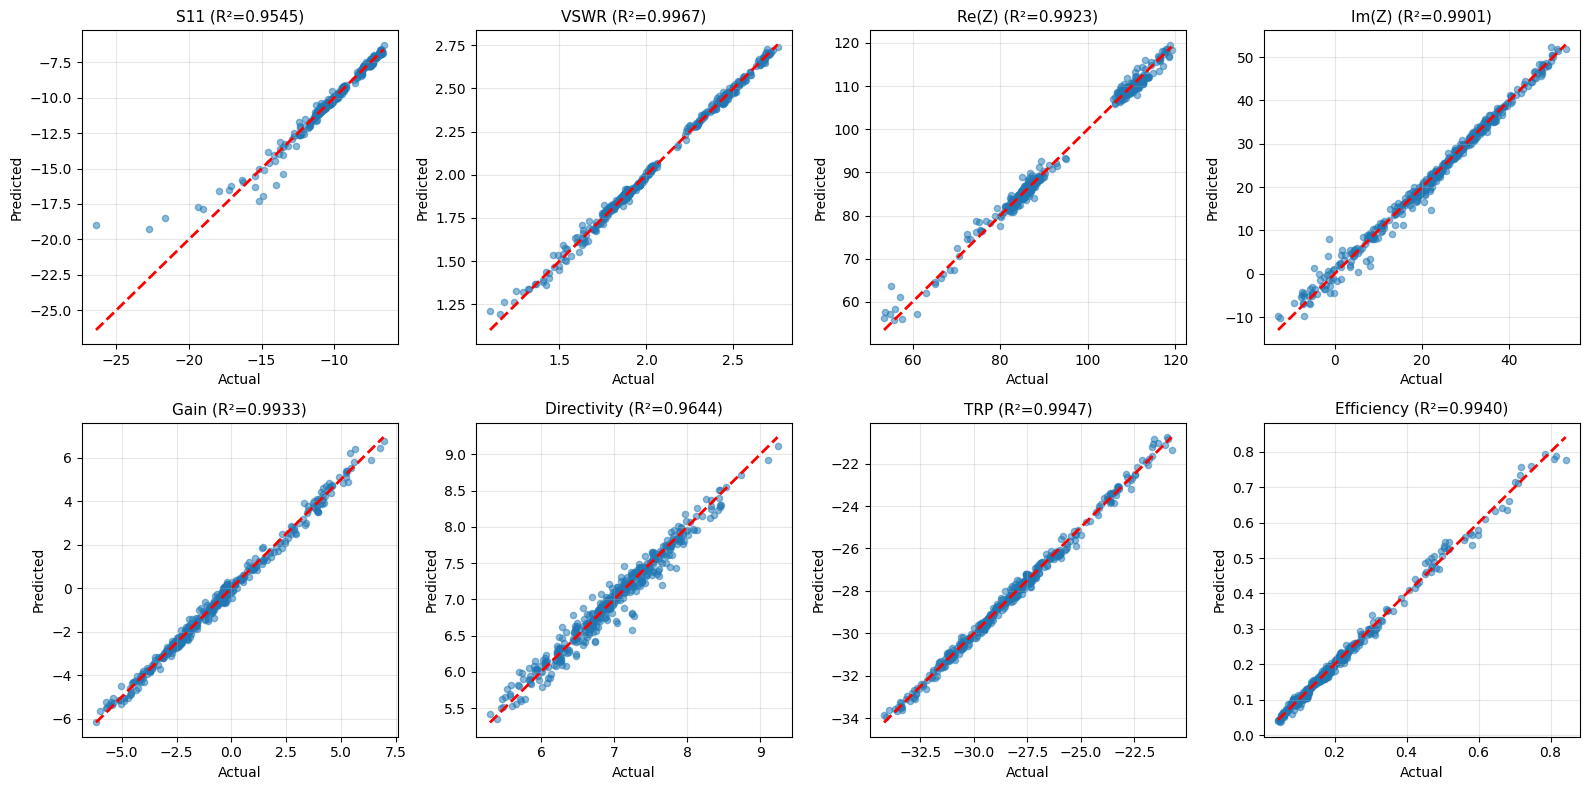

In [38]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, name in enumerate(output_names):
    ax = axes[i]
    ax.scatter(Y_test[:, i], Y_test_pred[:, i], alpha=0.5, s=20)
    ax.plot([Y_test[:, i].min(), Y_test[:, i].max()], 
            [Y_test[:, i].min(), Y_test[:, i].max()], 
            'r--', lw=2)
    ax.set_xlabel('Actual', fontsize=10)
    ax.set_ylabel('Predicted', fontsize=10)
    ax.set_title(f'{name} (R²={r2_score(Y_test[:, i], Y_test_pred[:, i]):.4f})', fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ANN_Predictions_vs_Actual.png', dpi=300)
plt.show()

**Error Distribution**

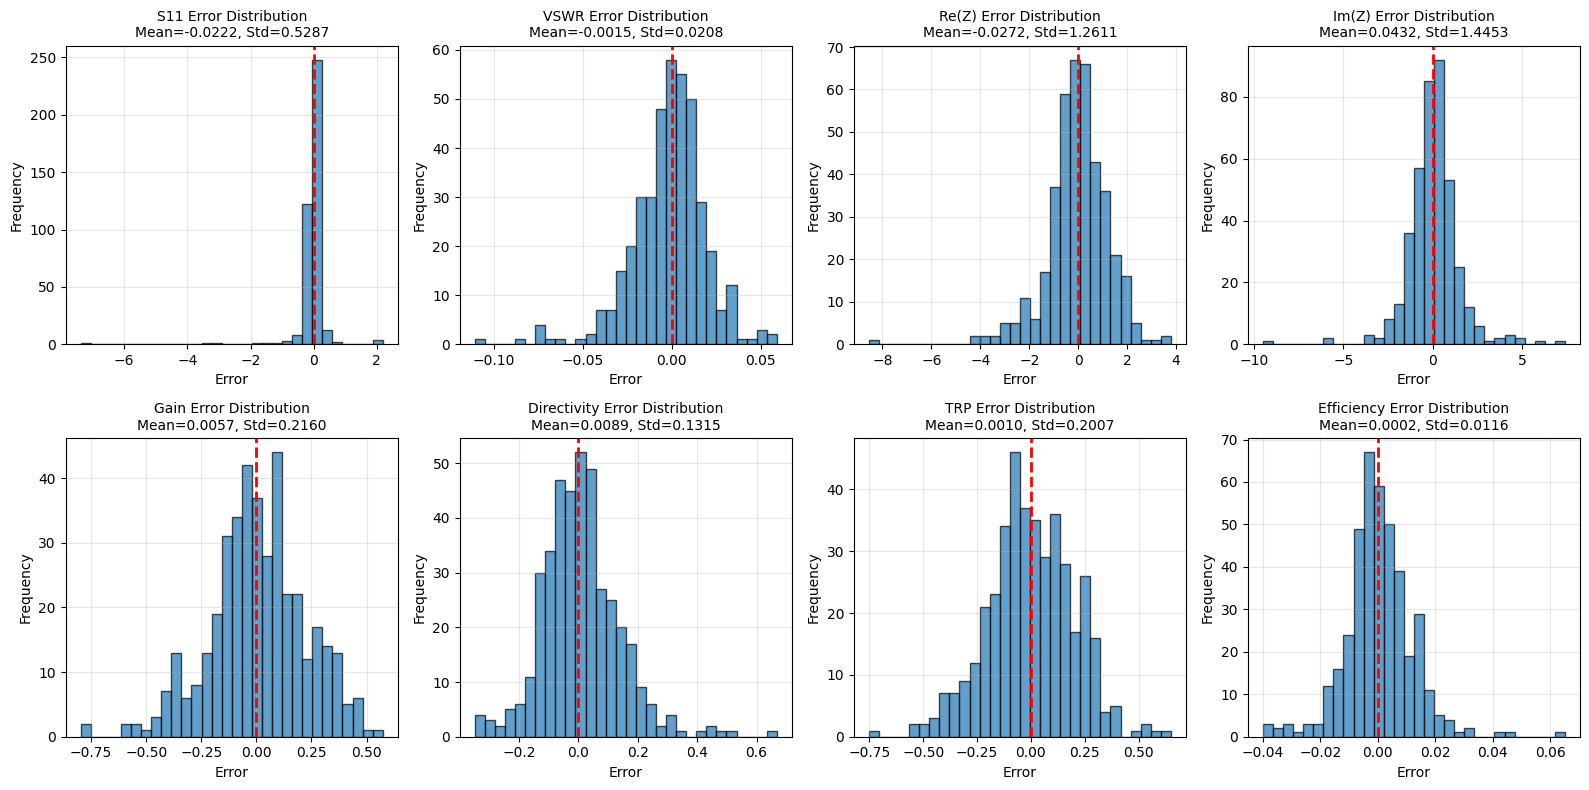

In [39]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, name in enumerate(output_names):
    ax = axes[i]
    ei = Y_test[:, i] - Y_test_pred[:, i]
    
    ax.hist(ei, bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('Error', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_title(f'{name} Error Distribution\nMean={ei.mean():.4f}, Std={ei.std():.4f}', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ANN_Error_Distribution.png', dpi=300)
plt.show()

**Prepare Data for Inverse Model**

In [40]:
print("="*70)
print("INVERSE MODEL: Performance → Geometry")
print("="*70)

X_inverse = Y
Y_inverse = X

X_inv_train, X_inv_temp, Y_inv_train, Y_inv_temp = train_test_split(
    X_inverse, Y_inverse, test_size=0.3, random_state=42
)
X_inv_val, X_inv_test, Y_inv_val, Y_inv_test = train_test_split(
    X_inv_temp, Y_inv_temp, test_size=0.5, random_state=42
)

print(f"Inverse X shape: {X_inverse.shape} (8 performance inputs)")
print(f"Inverse Y shape: {Y_inverse.shape} (11 geometry outputs)")
print(f"Train: {X_inv_train.shape[0]}, Val: {X_inv_val.shape[0]}, Test: {X_inv_test.shape[0]}")
print("="*70)

INVERSE MODEL: Performance → Geometry
Inverse X shape: (2700, 8) (8 performance inputs)
Inverse Y shape: (2700, 11) (11 geometry outputs)
Train: 1890, Val: 405, Test: 405


**Normalize Inverse Model Data**

In [41]:
scaler_X_inv = StandardScaler()
scaler_Y_inv = StandardScaler()

X_inv_train_scaled = scaler_X_inv.fit_transform(X_inv_train)
X_inv_val_scaled = scaler_X_inv.transform(X_inv_val)
X_inv_test_scaled = scaler_X_inv.transform(X_inv_test)

Y_inv_train_scaled = scaler_Y_inv.fit_transform(Y_inv_train)
Y_inv_val_scaled = scaler_Y_inv.transform(Y_inv_val)
Y_inv_test_scaled = scaler_Y_inv.transform(Y_inv_test)

print("Inverse model data normalization complete")

Inverse model data normalization complete


**Build and Train Inverse ANN**

In [42]:
ann_inverse = MLPRegressor(
    hidden_layer_sizes=(20, 15, 10),
    activation='tanh',
    solver='lbfgs',
    max_iter=1000,
    random_state=42,
    verbose=True
)

print("Training Inverse Model...")
ann_inverse.fit(X_inv_train_scaled, Y_inv_train_scaled)
print("Inverse model training complete")
print(f"Iterations: {ann_inverse.n_iter_}")
print(f"Loss: {ann_inverse.loss_:.6f}")

Training Inverse Model...
Inverse model training complete
Iterations: 1000
Loss: 0.051068


**Inverse Model Predictions**

In [43]:
Y_inv_train_pred_scaled = ann_inverse.predict(X_inv_train_scaled)
Y_inv_val_pred_scaled = ann_inverse.predict(X_inv_val_scaled)
Y_inv_test_pred_scaled = ann_inverse.predict(X_inv_test_scaled)

Y_inv_train_pred = scaler_Y_inv.inverse_transform(Y_inv_train_pred_scaled)
Y_inv_val_pred = scaler_Y_inv.inverse_transform(Y_inv_val_pred_scaled)
Y_inv_test_pred = scaler_Y_inv.inverse_transform(Y_inv_test_pred_scaled)

print("Inverse predictions complete")

Inverse predictions complete


**Inverse Model R² Scores**

In [44]:
inv_train_r2 = r2_score(Y_inv_train, Y_inv_train_pred)
inv_val_r2 = r2_score(Y_inv_val, Y_inv_val_pred)
inv_test_r2 = r2_score(Y_inv_test, Y_inv_test_pred)

print("="*70)
print("INVERSE MODEL R² SCORES")
print("="*70)
print(f"Train: {inv_train_r2:.4f}")
print(f"Val:   {inv_val_r2:.4f}")
print(f"Test:  {inv_test_r2:.4f}")
print("="*70)

INVERSE MODEL R² SCORES
Train: -20490874031327061615972341252096.0000
Val:   -22768202606329081342275421732864.0000
Test:  -20339580586499445688739693592576.0000


**Per-Parameter Performance (Inverse)**

In [45]:
param_names = ['Lp', 'Wp', 'Wf', 'hs', 'er', 'Ls', 'Ws', 'tp', 'tg', 'Lf', 'Freq']

print("\nPer-Parameter R² Scores (Inverse Model):")
print("="*60)
for i, name in enumerate(param_names):
    r2_test = r2_score(Y_inv_test[:, i], Y_inv_test_pred[:, i])
    print(f"{name:8s} | Test R²: {r2_test:.4f}")


Per-Parameter R² Scores (Inverse Model):
Lp       | Test R²: 0.7679
Wp       | Test R²: 0.3307
Wf       | Test R²: 0.6229
hs       | Test R²: 0.9943
er       | Test R²: 0.0000
Ls       | Test R²: -71153367250240250964969783296.0000
Ws       | Test R²: -5588889912466923103113059500032.0000
tp       | Test R²: -40952094273800787634078360587468800.0000
tg       | Test R²: -1416348656935300067778697644474368.0000
Lf       | Test R²: -213730374968330667768022107684864.0000
Freq     | Test R²: 0.9681


In [46]:
print("="*70)
print("PARAMETER VARIATION ANALYSIS")
print("="*70)
for i, name in enumerate(param_names):
    param_values = X[:, i]
    unique_count = len(np.unique(param_values))
    min_val = param_values.min()
    max_val = param_values.max()
    std_val = param_values.std()
    
    print(f"{name:8s} | Unique: {unique_count:4d} | Min: {min_val:.6f} | Max: {max_val:.6f} | Std: {std_val:.6f}")
print("="*70)

PARAMETER VARIATION ANALYSIS
Lp       | Unique:    3 | Min: 0.003700 | Max: 0.003900 | Std: 0.000082
Wp       | Unique:    3 | Min: 0.005700 | Max: 0.006000 | Std: 0.000124
Wf       | Unique:    2 | Min: 0.000200 | Max: 0.000220 | Std: 0.000010
hs       | Unique:    2 | Min: 0.001574 | Max: 0.001800 | Std: 0.000113
er       | Unique:    1 | Min: 3.000000 | Max: 3.000000 | Std: 0.000000
Ls       | Unique:    1 | Min: 0.029500 | Max: 0.029500 | Std: 0.000000
Ws       | Unique:    1 | Min: 0.007000 | Max: 0.007000 | Std: 0.000000
tp       | Unique:    1 | Min: 0.000035 | Max: 0.000035 | Std: 0.000000
tg       | Unique:    1 | Min: 0.000500 | Max: 0.000500 | Std: 0.000000
Lf       | Unique:    1 | Min: 0.001000 | Max: 0.001000 | Std: 0.000000
Freq     | Unique:   75 | Min: 16.000000 | Max: 19.000000 | Std: 0.877650


**Prepare Reduced Inverse Model**

In [47]:
variable_indices = [0, 1, 2, 3, 10]
variable_param_names = ['Lp', 'Wp', 'Wf', 'hs', 'Freq']

X_inverse_reduced = Y
Y_inverse_reduced = X[:, variable_indices]

X_invr_train, X_invr_temp, Y_invr_train, Y_invr_temp = train_test_split(
    X_inverse_reduced, Y_inverse_reduced, test_size=0.3, random_state=42
)
X_invr_val, X_invr_test, Y_invr_val, Y_invr_test = train_test_split(
    X_invr_temp, Y_invr_temp, test_size=0.5, random_state=42
)

print("="*70)
print("REDUCED INVERSE MODEL: Performance → Variable Geometry Only")
print("="*70)
print(f"Input: 8 performance metrics")
print(f"Output: {len(variable_param_names)} variable parameters: {variable_param_names}")
print(f"Train: {X_invr_train.shape[0]}, Val: {X_invr_val.shape[0]}, Test: {X_invr_test.shape[0]}")
print("="*70)

REDUCED INVERSE MODEL: Performance → Variable Geometry Only
Input: 8 performance metrics
Output: 5 variable parameters: ['Lp', 'Wp', 'Wf', 'hs', 'Freq']
Train: 1890, Val: 405, Test: 405


**Normalize and Train Reduced Inverse Model**

In [48]:
scaler_X_invr = StandardScaler()
scaler_Y_invr = StandardScaler()

X_invr_train_scaled = scaler_X_invr.fit_transform(X_invr_train)
X_invr_val_scaled = scaler_X_invr.transform(X_invr_val)
X_invr_test_scaled = scaler_X_invr.transform(X_invr_test)

Y_invr_train_scaled = scaler_Y_invr.fit_transform(Y_invr_train)
Y_invr_val_scaled = scaler_Y_invr.transform(Y_invr_val)
Y_invr_test_scaled = scaler_Y_invr.transform(Y_invr_test)

ann_inverse_reduced = MLPRegressor(
    hidden_layer_sizes=(20, 15, 10),
    activation='tanh',
    solver='lbfgs',
    max_iter=1000,
    random_state=42,
    verbose=True
)

print("Training Reduced Inverse Model...")
ann_inverse_reduced.fit(X_invr_train_scaled, Y_invr_train_scaled)
print("Training complete")
print(f"Iterations: {ann_inverse_reduced.n_iter_}")
print(f"Loss: {ann_inverse_reduced.loss_:.6f}")

Training Reduced Inverse Model...


Training complete
Iterations: 1000
Loss: 0.111755


**Evaluate Reduced Inverse Model**

In [49]:
Y_invr_test_pred_scaled = ann_inverse_reduced.predict(X_invr_test_scaled)
Y_invr_test_pred = scaler_Y_invr.inverse_transform(Y_invr_test_pred_scaled)

invr_test_r2 = r2_score(Y_invr_test, Y_invr_test_pred)

print("="*70)
print("REDUCED INVERSE MODEL RESULTS")
print("="*70)
print(f"Overall Test R²: {invr_test_r2:.4f}")
print("\nPer-Parameter R²:")
for i, name in enumerate(variable_param_names):
    r2 = r2_score(Y_invr_test[:, i], Y_invr_test_pred[:, i])
    print(f"{name:8s} | Test R²: {r2:.4f}")
print("="*70)

REDUCED INVERSE MODEL RESULTS
Overall Test R²: 0.7483

Per-Parameter R²:
Lp       | Test R²: 0.7818
Wp       | Test R²: 0.3549
Wf       | Test R²: 0.6430
hs       | Test R²: 0.9998
Freq     | Test R²: 0.9622


** Optimization Example - Find Geometry for Target Performance**

In [50]:
print("="*70)
print("OPTIMIZATION DEMONSTRATION")
print("="*70)

target_performance = np.array([[
    -20.0,
    1.2,
    50.0,
    5.0,
    6.0,
    7.0,
    -25.0,
    0.9
]])

print("\nTarget Performance:")
for i, name in enumerate(output_names):
    print(f"  {name:12s}: {target_performance[0, i]:.4f}")

target_scaled = scaler_X_invr.transform(target_performance)
predicted_geometry_scaled = ann_inverse_reduced.predict(target_scaled)
predicted_geometry = scaler_Y_invr.inverse_transform(predicted_geometry_scaled)

print("\nPredicted Geometry:")
for i, name in enumerate(variable_param_names):
    print(f"  {name:8s}: {predicted_geometry[0, i]:.6f}")

full_geometry = np.array([[
    predicted_geometry[0, 0],
    predicted_geometry[0, 1],
    predicted_geometry[0, 2],
    predicted_geometry[0, 3],
    3.0,
    0.0295,
    0.007,
    0.000035,
    0.0005,
    0.001,
    predicted_geometry[0, 4]
]])

full_geometry_scaled = scaler_X.transform(full_geometry)
achieved_performance_scaled = ann_model.predict(full_geometry_scaled)
achieved_performance = scaler_Y.inverse_transform(achieved_performance_scaled)

print("\nAchieved Performance (Forward Model Verification):")
for i, name in enumerate(output_names):
    target_val = target_performance[0, i]
    achieved_val = achieved_performance[0, i]
    error = abs(target_val - achieved_val)
    print(f"  {name:12s}: Target={target_val:7.4f}, Achieved={achieved_val:7.4f}, Error={error:.4f}")
print("="*70)

OPTIMIZATION DEMONSTRATION

Target Performance:
  S11         : -20.0000
  VSWR        : 1.2000
  Re(Z)       : 50.0000
  Im(Z)       : 5.0000
  Gain        : 6.0000
  Directivity : 7.0000
  TRP         : -25.0000
  Efficiency  : 0.9000

Predicted Geometry:
  Lp      : 0.003884
  Wp      : 0.005819
  Wf      : 0.000197
  hs      : 0.001802
  Freq    : 18.413945

Achieved Performance (Forward Model Verification):
  S11         : Target=-20.0000, Achieved=-12.1981, Error=7.8019
  VSWR        : Target= 1.2000, Achieved= 1.6663, Error=0.4663
  Re(Z)       : Target=50.0000, Achieved=81.6660, Error=31.6660
  Im(Z)       : Target= 5.0000, Achieved=-7.5857, Error=12.5857
  Gain        : Target= 6.0000, Achieved= 3.9187, Error=2.0813
  Directivity : Target= 7.0000, Achieved= 5.5548, Error=1.4452
  TRP         : Target=-25.0000, Achieved=-21.9314, Error=3.0686
  Efficiency  : Target= 0.9000, Achieved= 0.6154, Error=0.2846


**Grid Search for Optimal Architecture**

In [51]:
from sklearn.model_selection import GridSearchCV

print("="*70)
print("HYPERPARAMETER TUNING WITH CROSS-VALIDATION")
print("="*70)

param_grid = {
    'hidden_layer_sizes': [
        (20, 15, 10),
        (30, 20, 10),
        (25, 15),
        (40, 30, 20),
        (15, 10, 5)
    ],
    'activation': ['tanh', 'relu'],
    'alpha': [0.0001, 0.001, 0.01]
}

ann_grid = MLPRegressor(
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=ann_grid,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

print("Starting Grid Search with 5-fold cross-validation...")
print(f"Total combinations to test: {len(param_grid['hidden_layer_sizes']) * len(param_grid['activation']) * len(param_grid['alpha'])}")

HYPERPARAMETER TUNING WITH CROSS-VALIDATION
Starting Grid Search with 5-fold cross-validation...
Total combinations to test: 30


**Display Best Parameters**

In [52]:
grid_search.fit(X_train_scaled, Y_train_scaled)

print("\n" + "="*70)
print("GRID SEARCH RESULTS")
print("="*70)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation R²: {grid_search.best_score_:.4f}")
print(f"Our original model R² (test): {test_r2:.4f}")
print("="*70)

best_ann = grid_search.best_estimator_

Y_test_pred_best_scaled = best_ann.predict(X_test_scaled)
Y_test_pred_best = scaler_Y.inverse_transform(Y_test_pred_best_scaled)
test_r2_best = r2_score(Y_test, Y_test_pred_best)

print(f"\nOptimized model Test R²: {test_r2_best:.4f}")
print(f"Improvement: {(test_r2_best - test_r2):.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

GRID SEARCH RESULTS
Best parameters: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (40, 30, 20)}
Best cross-validation R²: 0.9943
Our original model R² (test): 0.9850

Optimized model Test R²: 0.9946
Improvement: 0.0096


**K-Fold Cross-Validation Analysis**

In [53]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    ann_model, 
    X_train_scaled, 
    Y_train_scaled, 
    cv=5, 
    scoring='r2'
)

print("="*70)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("="*70)
print(f"Fold 1 R²: {cv_scores[0]:.4f}")
print(f"Fold 2 R²: {cv_scores[1]:.4f}")
print(f"Fold 3 R²: {cv_scores[2]:.4f}")
print(f"Fold 4 R²: {cv_scores[3]:.4f}")
print(f"Fold 5 R²: {cv_scores[4]:.4f}")
print(f"\nMean R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("="*70)

5-FOLD CROSS-VALIDATION RESULTS
Fold 1 R²: 0.9854
Fold 2 R²: 0.9847
Fold 3 R²: 0.9822
Fold 4 R²: 0.9879
Fold 5 R²: 0.9871

Mean R²: 0.9854 ± 0.0020


**Plot Learning Curves**

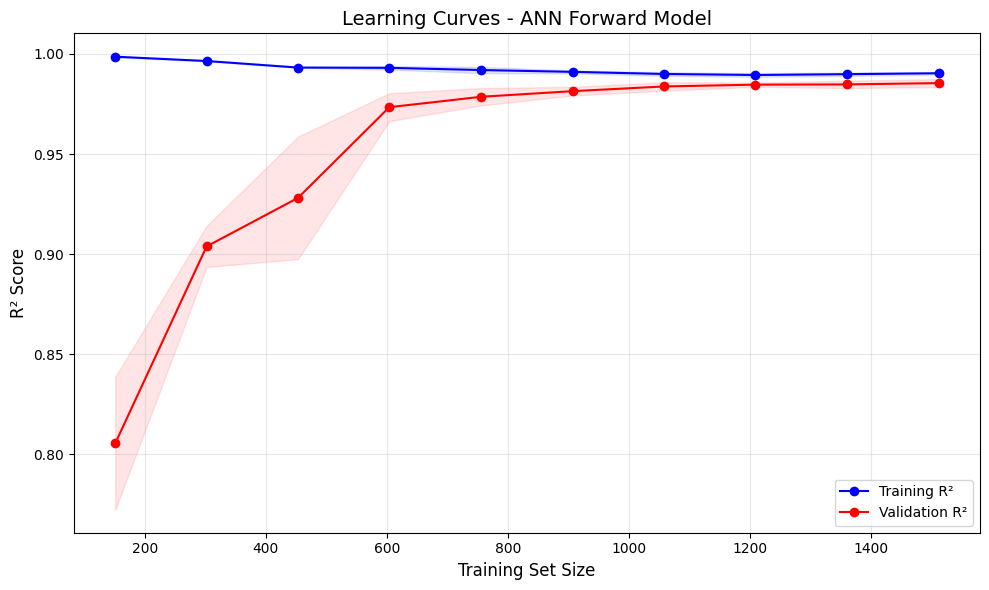

Final training R²: 0.9904 ± 0.0006
Final validation R²: 0.9854 ± 0.0020
Gap (overfitting indicator): 0.0049


In [54]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    ann_model,
    X_train_scaled,
    Y_train_scaled,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='r2'
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training R²')
plt.plot(train_sizes, val_mean, 'o-', color='red', label='Validation R²')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='red')
plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('Learning Curves - ANN Forward Model', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Learning_Curves.png', dpi=300)
plt.show()

print(f"Final training R²: {train_mean[-1]:.4f} ± {train_std[-1]:.4f}")
print(f"Final validation R²: {val_mean[-1]:.4f} ± {val_std[-1]:.4f}")
print(f"Gap (overfitting indicator): {train_mean[-1] - val_mean[-1]:.4f}")

**Permutation Feature Importance**

FEATURE IMPORTANCE ANALYSIS
Feature  Importance      Std
   Freq    2.664971 0.593649
     hs    1.825350 0.540287
     Lp    0.260464 0.364659
     Wp    0.228136 0.073686
     Wf    0.166334 0.098420
     Ls    0.000000 0.000000
     er    0.000000 0.000000
     Ws    0.000000 0.000000
     tp    0.000000 0.000000
     tg    0.000000 0.000000
     Lf    0.000000 0.000000


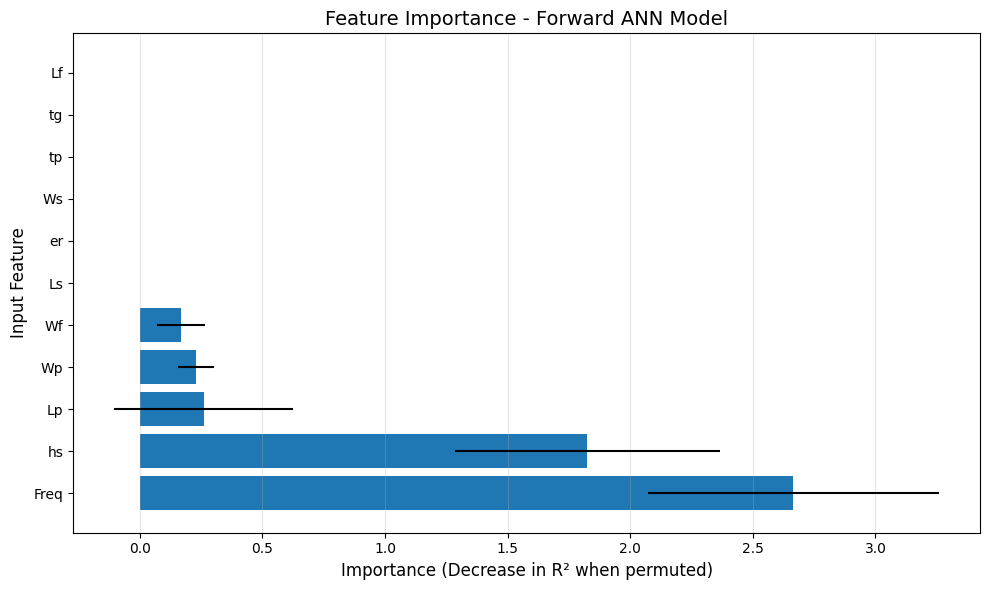

In [55]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    ann_model,
    X_test_scaled,
    Y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_mean = perm_importance.importances_mean
importance_std = perm_importance.importances_std

feature_importance_df = pd.DataFrame({
    'Feature': ['Lp', 'Wp', 'Wf', 'hs', 'er', 'Ls', 'Ws', 'tp', 'tg', 'Lf', 'Freq'],
    'Importance': importance_mean,
    'Std': importance_std
}).sort_values('Importance', ascending=False)

print("="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70)
print(feature_importance_df.to_string(index=False))
print("="*70)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], xerr=feature_importance_df['Std'])
plt.xlabel('Importance (Decrease in R² when permuted)', fontsize=12)
plt.ylabel('Input Feature', fontsize=12)
plt.title('Feature Importance - Forward ANN Model', fontsize=14)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('Feature_Importance.png', dpi=300)
plt.show()

**Residual Analysis for Each Output**

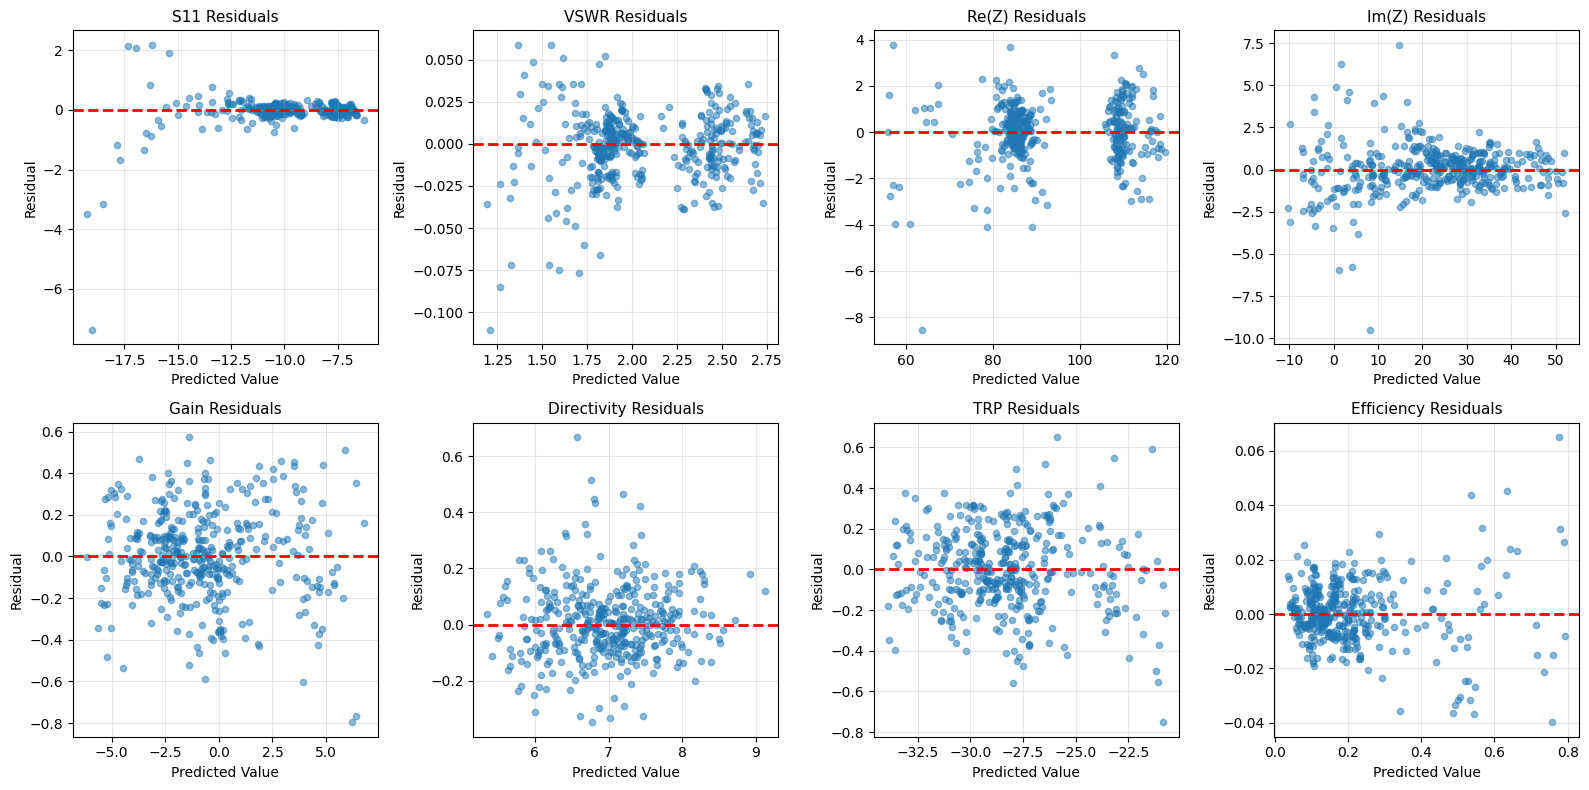

RESIDUAL ANALYSIS
S11          | Mean:  -0.0222 | Std:   0.5287
VSWR         | Mean:  -0.0015 | Std:   0.0208
Re(Z)        | Mean:  -0.0272 | Std:   1.2611
Im(Z)        | Mean:   0.0432 | Std:   1.4453
Gain         | Mean:   0.0057 | Std:   0.2160
Directivity  | Mean:   0.0089 | Std:   0.1315
TRP          | Mean:   0.0010 | Std:   0.2007
Efficiency   | Mean:   0.0002 | Std:   0.0116


In [56]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, name in enumerate(output_names):
    ax = axes[i]
    
    residuals = Y_test[:, i] - Y_test_pred[:, i]
    
    ax.scatter(Y_test_pred[:, i], residuals, alpha=0.5, s=20)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('Predicted Value', fontsize=10)
    ax.set_ylabel('Residual', fontsize=10)
    ax.set_title(f'{name} Residuals', fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Residual_Plots.png', dpi=300)
plt.show()

print("="*70)
print("RESIDUAL ANALYSIS")
print("="*70)
for i, name in enumerate(output_names):
    residuals = Y_test[:, i] - Y_test_pred[:, i]
    print(f"{name:12s} | Mean: {residuals.mean():8.4f} | Std: {residuals.std():8.4f}")
print("="*70)

**Sensitivity to Input Noise**

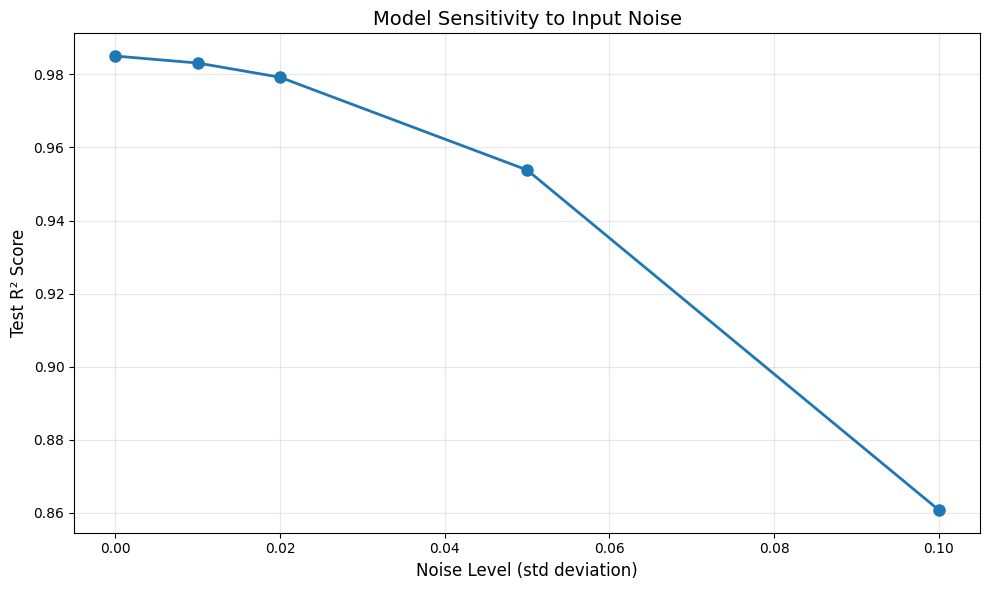

SENSITIVITY ANALYSIS
Noise: 0.00 | R²: 0.9850 | Degradation: 0.0000
Noise: 0.01 | R²: 0.9831 | Degradation: 0.0019
Noise: 0.02 | R²: 0.9792 | Degradation: 0.0058
Noise: 0.05 | R²: 0.9538 | Degradation: 0.0312
Noise: 0.10 | R²: 0.8608 | Degradation: 0.1242


In [57]:
noise_levels = [0.0, 0.01, 0.02, 0.05, 0.10]
r2_scores_noise = []

for noise_level in noise_levels:
    X_test_noisy = X_test_scaled + np.random.normal(0, noise_level, X_test_scaled.shape)
    Y_test_pred_noisy_scaled = ann_model.predict(X_test_noisy)
    Y_test_pred_noisy = scaler_Y.inverse_transform(Y_test_pred_noisy_scaled)
    r2_noisy = r2_score(Y_test, Y_test_pred_noisy)
    r2_scores_noise.append(r2_noisy)

plt.figure(figsize=(10, 6))
plt.plot(noise_levels, r2_scores_noise, 'o-', linewidth=2, markersize=8)
plt.xlabel('Noise Level (std deviation)', fontsize=12)
plt.ylabel('Test R² Score', fontsize=12)
plt.title('Model Sensitivity to Input Noise', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Sensitivity_Analysis.png', dpi=300)
plt.show()

print("="*70)
print("SENSITIVITY ANALYSIS")
print("="*70)
for noise, r2 in zip(noise_levels, r2_scores_noise):
    degradation = test_r2 - r2
    print(f"Noise: {noise:.2f} | R²: {r2:.4f} | Degradation: {degradation:.4f}")
print("="*70)

**Save Models**

In [58]:
import pickle

models = {
    'forward_model': ann_model,
    'inverse_model_reduced': ann_inverse_reduced,
    'scaler_X_forward': scaler_X,
    'scaler_Y_forward': scaler_Y,
    'scaler_X_inverse': scaler_X_invr,
    'scaler_Y_inverse': scaler_Y_invr,
    'variable_param_names': variable_param_names,
    'output_names': output_names,
    'variable_indices': variable_indices
}

with open('ANN_models.pkl', 'wb') as f:
    pickle.dump(models, f)

print("Models saved to ANN_models.pkl")

Models saved to ANN_models.pkl
